# Print Results

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import deepinv as dinv
from deepinv.physics import Denoising, GaussianNoise, PoissonNoise
from deepinv.utils.demo import load_url_image, get_image_url
from deepinv.utils.plotting import plot

from opt_functions.plot_results import *
from opt_functions.Solver_functions.white_opt_princ import *
        
import ISM.simulation.PSF_sim as ism
import ISM.analysis.Graph_lib as gr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

Using device: cuda


Sto cercando in: /data/cil/sofia/ism_regularisation/Results/ism_results/ism_3D_real_rl_01_tomm20_lam0_iter10000.pth


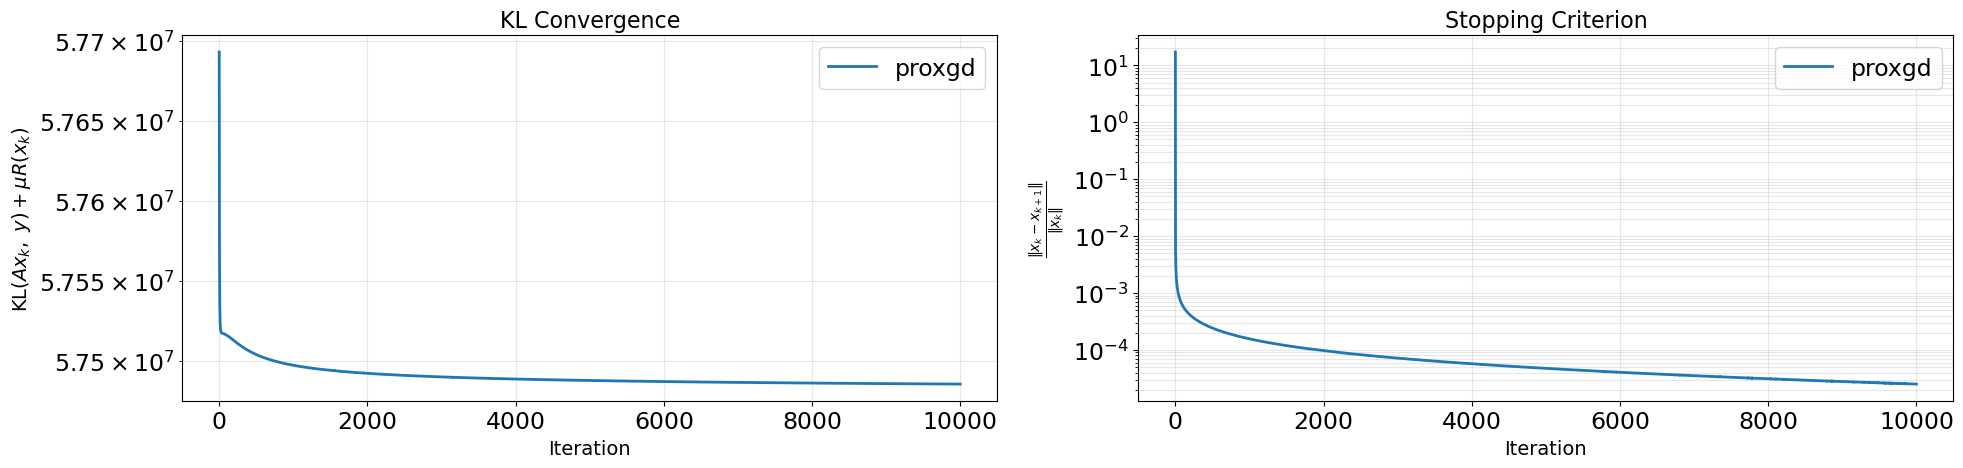

ValueError: x, y, and format string must not be None

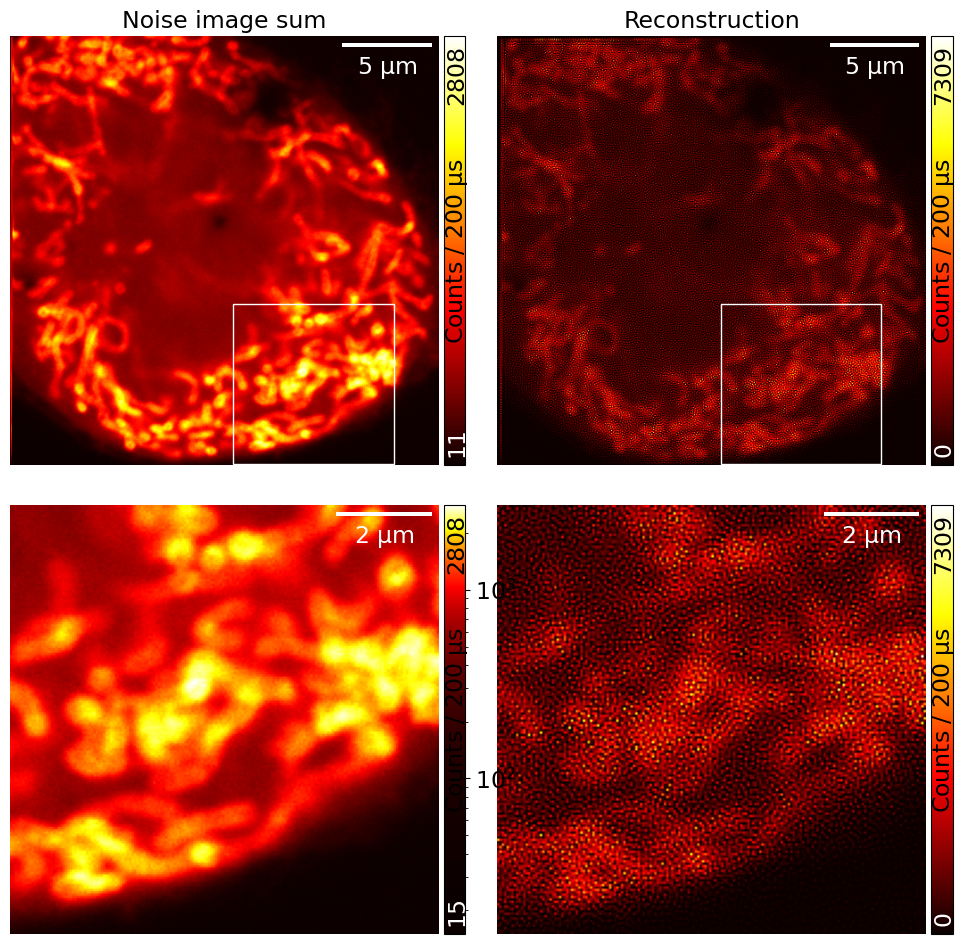

In [10]:
lam_to_load = 0

algo_to_load = "rl"                # pgd or prox or md
name_to_load = "01_tomm20"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D
real_to_load = "real"               # real o sim

path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}_iter10000.pth"
# path = "Results/ism_results/ism_tv_3D_sim_md_tubulin_lam0.05152.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

# Nel codice di caricamento
full_path_load = os.path.abspath(path)
print(f"Sto cercando in: {full_path_load}")


plot_results(results, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 300, y0_sec = 250)

norm2 = results['norm2']

plt.semilogy(norm2)
plt.title("Norm 2 to ground-truth", fontsize=16)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel(r"$||x_k - x_{\mathrm{GT}})||_2$", fontsize=14)

In [13]:
print(norm2)

None


In [15]:
L = torch.zeros(25)
for j in range(0,25):
    x_ones = torch.ones_like(dataset['ground_truth'].repeat(25,1,1,1))
    norm_H = torch.max(dataset["physics"](x_ones)[j]) * torch.max(dataset["physics"].A_adjoint(x_ones)[j])
    norm_y = torch.max(torch.abs(dataset['noise_image'][j]))
    L[j] = (norm_y / dataset["back"][j]**2)* norm_H
L_th = torch.sum(L)

KeyError: 'physics'

pgd
PSNR 18.991369247436523
SSIM 0.6416492462158203
MICROSSIM 0.6945886511956915
prox
PSNR 20.252342224121094
SSIM 0.7206780910491943
MICROSSIM 0.72428675482319


/nethome/sagostoni/.conda/envs/sofi_py310/lib/python3.10/site-packages/microssim/ssim/ssim_utils.py:297: RuntimeWarning: invalid value encountered in sqrt
  term = 2 * alpha * np.sqrt(elements.vx * elements.vy) + elements.C2


md
PSNR 16.73110580444336
SSIM 0.5570752620697021
MICROSSIM 0.6201144084959775
md_l1
PSNR 17.31717300415039
SSIM 0.5927936434745789
MICROSSIM 0.6837797180071259
rl
PSNR 17.62436294555664
SSIM 0.40997791290283203
MICROSSIM 0.5299911917513309


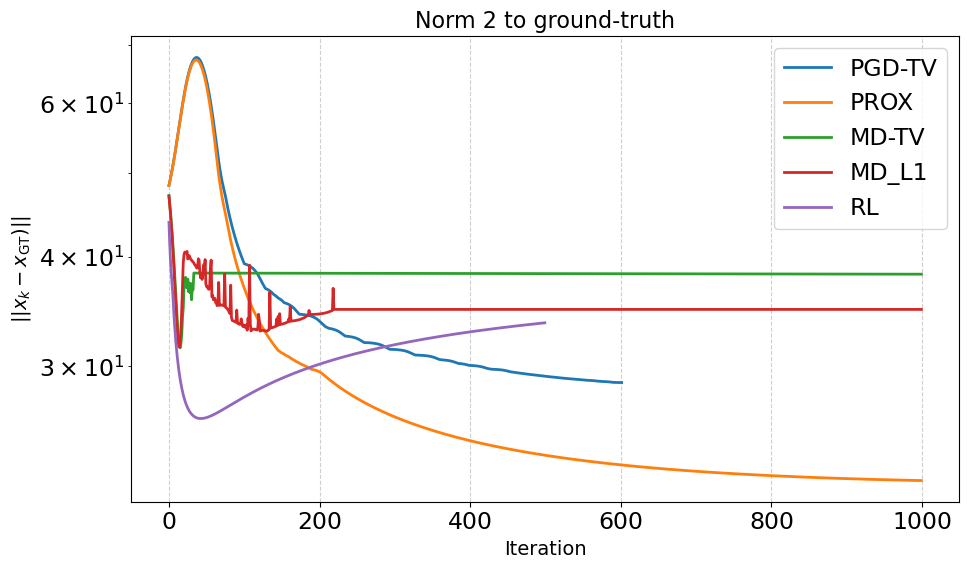

In [3]:
sec = "3D"

list_methods_tub2D = [("pgd", 0.00672), ("prox", 0.0805), ("md", 0.0537), ("md_l1", 0.0505), ("rl", 0)]
list_methods_tub3D = [("pgd", 0.0134), ("prox", 0.0268), ("md", 0.309), ("md_l1", 0.0909), ("rl",0)]


# 1. Inizializza la figura fuori dal loop
plt.figure(figsize=(10, 6))

for method, lam in list_methods_tub3D:
    # Parametri di caricamento
    algo_to_load = 'md' if method == "md_l1" else method
    lam_to_load = lam
    name_to_load = "tubulin"
    sect_to_load = "3D"
    real_to_load = "sim"
    
    if method == "rl":
        path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}_iter500.pth"
        
    elif method == "md_l1":
        path = f"Results/ism_results/ism_l1_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"
        
    else:
        path = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_{algo_to_load}_{name_to_load}_lam{lam_to_load}.pth"


    # 2. Carica il checkpoint
    checkpoint = torch.load(path, weights_only=False, map_location='cpu')
    results = checkpoint['results']
    y_values = results['norm2']
    print(method)
    print(f"PSNR {results['psnr'][-1].item()}")
    print(f"SSIM {results['ssim'][-1].item()}")
    print(f"MICROSSIM {micro_structural_similarity(checkpoint['dataset']['ground_truth'][:,1:2].squeeze().detach().cpu().numpy().astype(np.float32), results['x_result'][:,1:2].squeeze().detach().cpu().numpy().astype(np.float32))}")

    # Recupera la funzione KL (assumendo sia nel dizionario results)
    # Sostituisci 'kl_funct' con la chiave corretta se diversa
    # y_values = results['kl_funct'][50:].cpu().numpy()
    label = f"{method.upper()}-TV" if method == "pgd" or method == "md" else f"{method.upper()}"
    # 3. Plot della curva con 'label' per la legenda
    plt.semilogy(y_values[:1000], label=label)


# 4. Abbellimento del grafico (fuori dal loop)
plt.title("Norm 2 to ground-truth", fontsize=16)
plt.xlabel("Iteration", fontsize=14)
plt.ylabel(r"$||x_k - x_{\mathrm{GT}})||$", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Questo genera la legenda usando i 'label' definiti nel plt.plot
plt.tight_layout() # Ottimizza gli spazi

# 5. Mostra il grafico finale con tutte le curve
plt.show()





In [109]:
results_best.keys()

dict_keys(['x_result', 'funct', 'iter_err', 'diff_fid', 'psnr', 'ssim', 'norm2'])

# WHITE PRINCIPLE

2.42e-01
--- Risultati per WP ---
Mu ottimale (min WP): 0.000000e+00 con WP = 2.000147e+00
Mu ottimale (max PSNR): 1.343268e-02 con PSNR = 21.1461 dB
Mu ottimale (max SSIM): 6.721342e-03 con SSIM = 0.7077



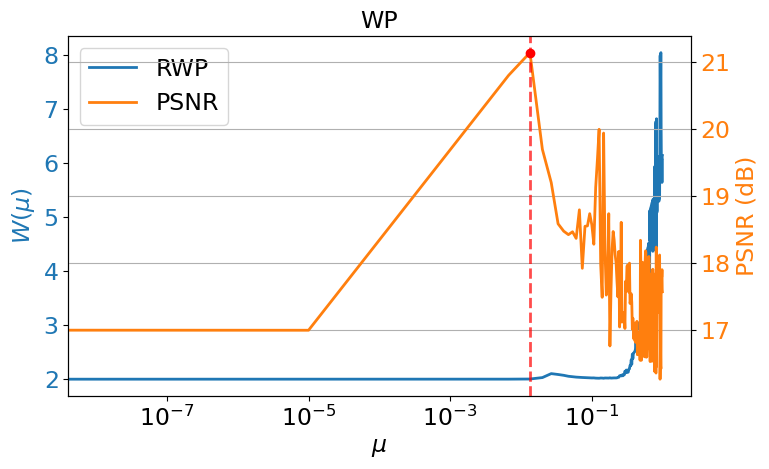

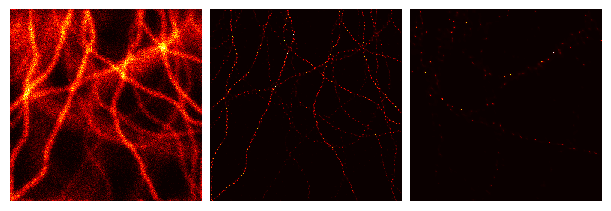

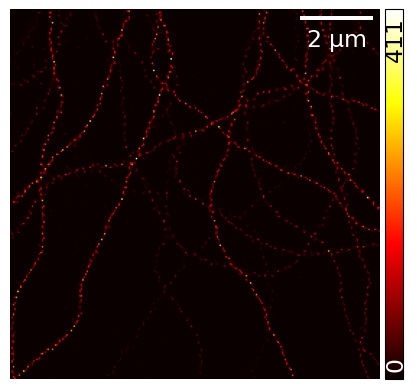

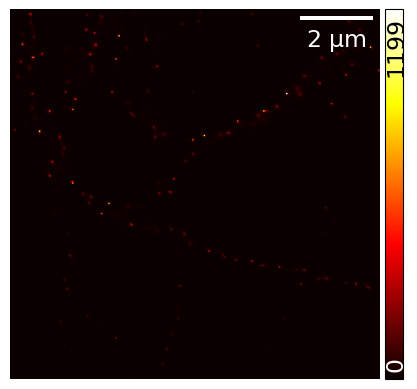

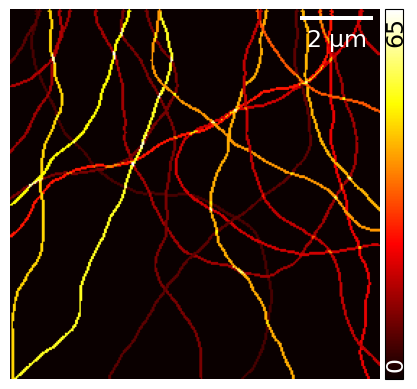

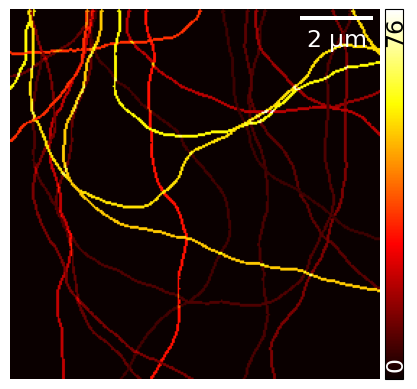

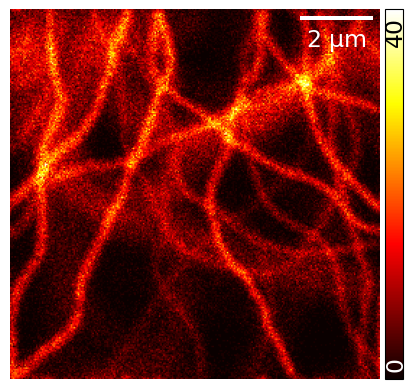

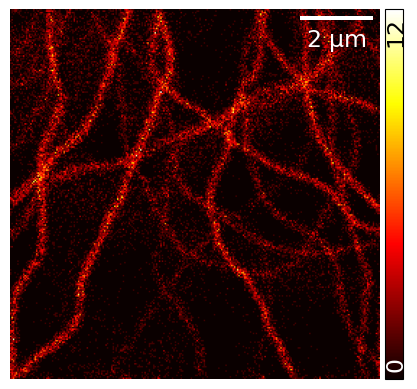

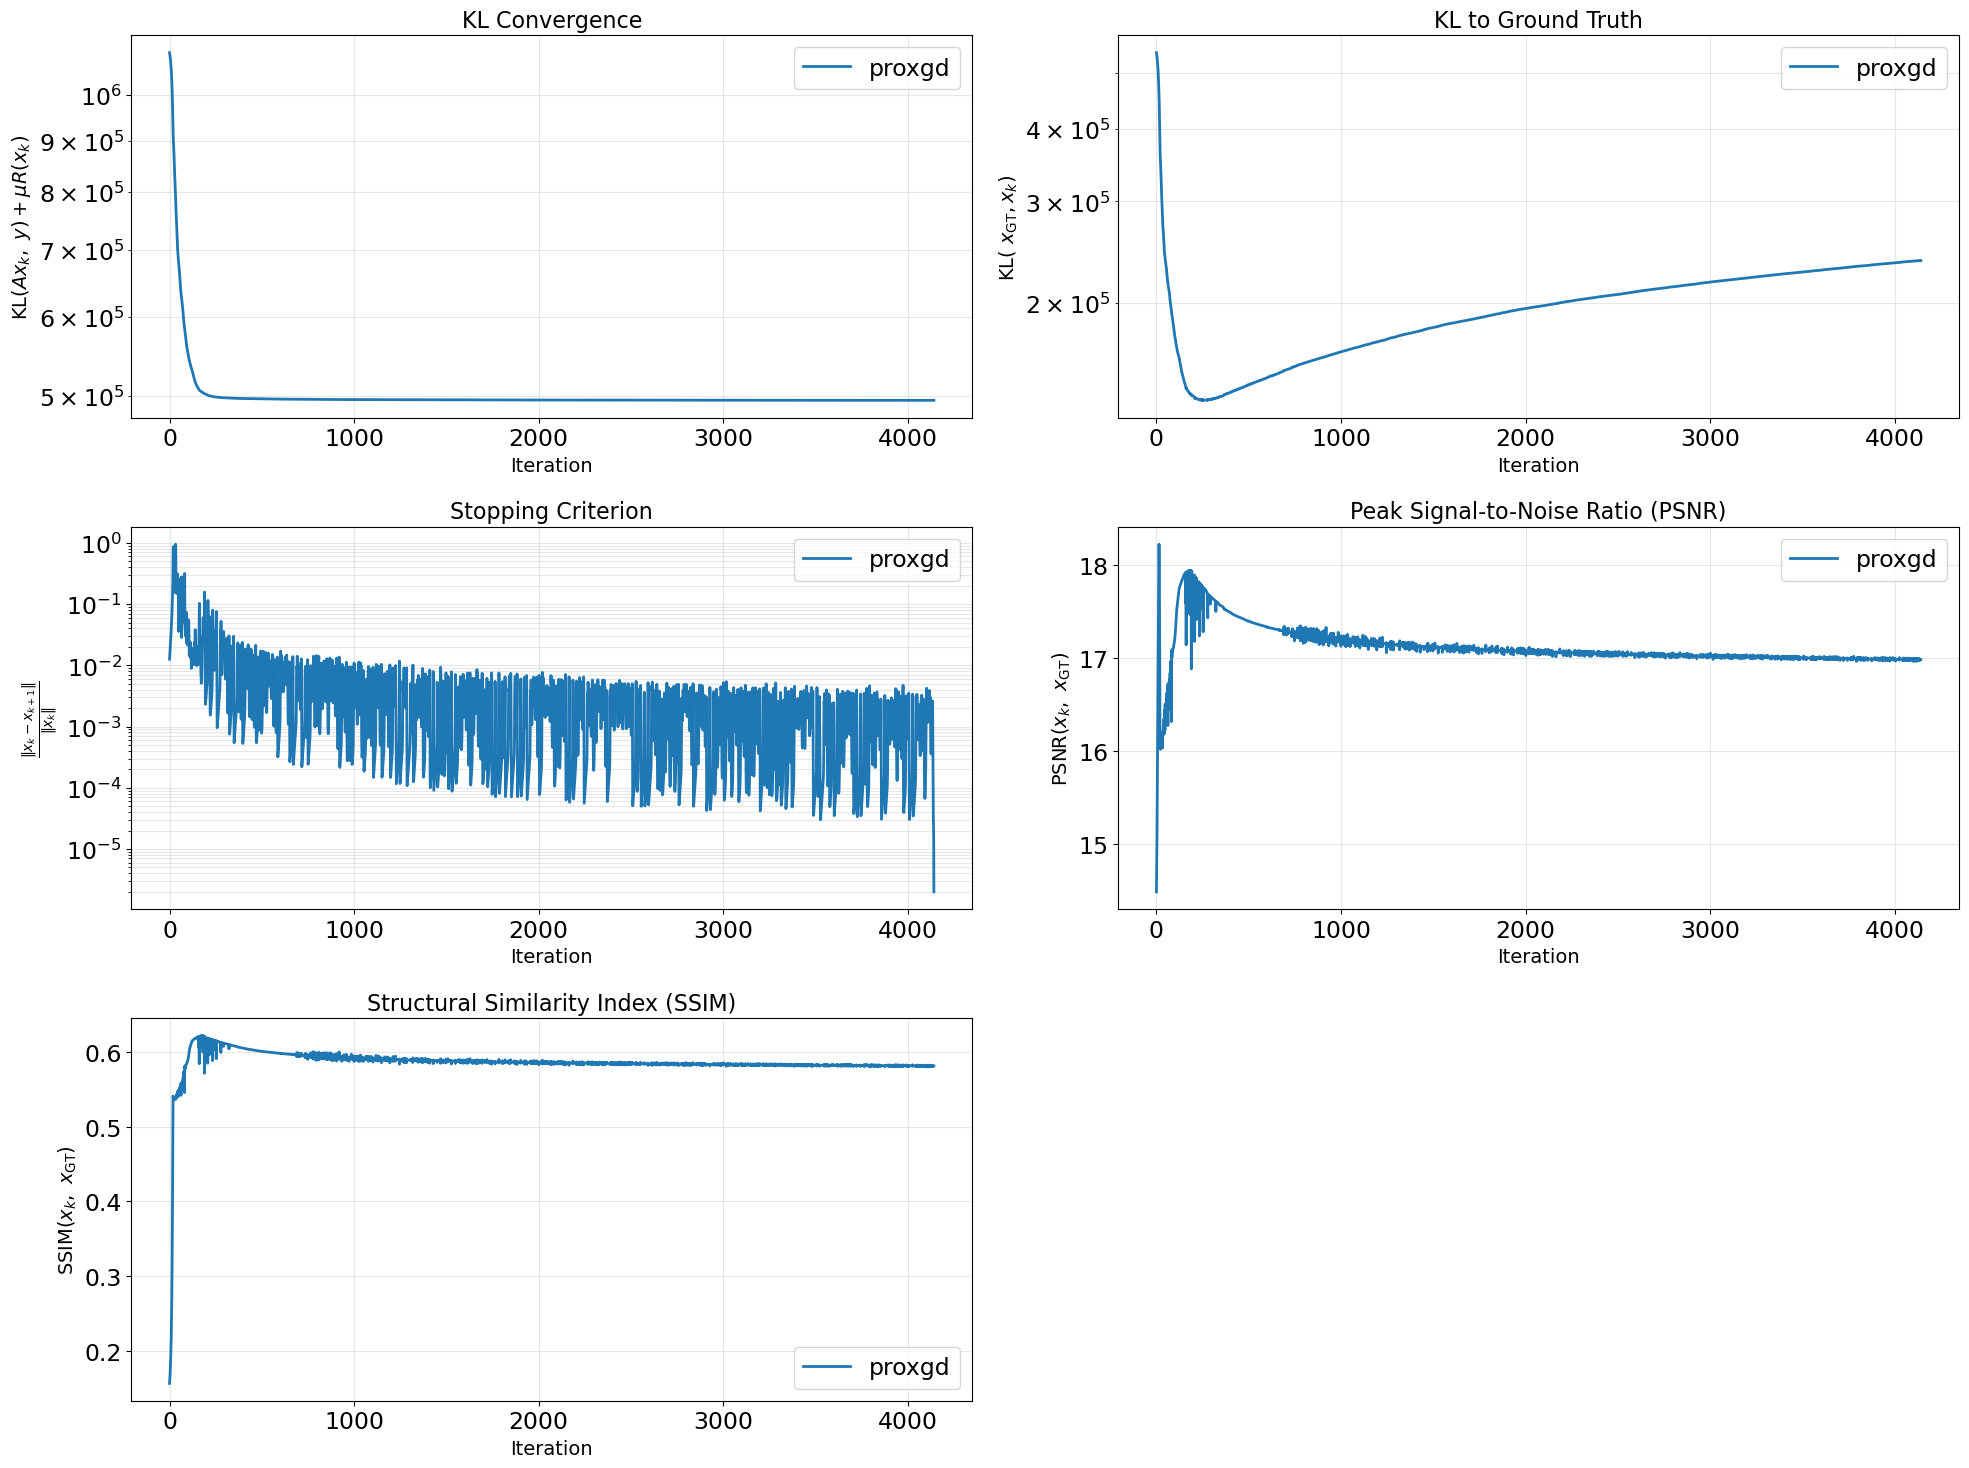

PSNR 16.984432220458984
SSIM 0.5813356637954712
MICROSSIM 0.6555757881420785


FileNotFoundError: [Errno 2] No such file or directory: 'percorso/della/cartella/immagine.png'

In [108]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                # whole, masked, masked_eps
algo_to_load = "md"                # pgd or prox or md
name_to_load = "tubulin"            # tubulin for sim 05_convallaria
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_newgrid_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"

checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']

best_mu = find_knee_point(hparams['mu_grid'].cpu(),results['W_sum'].cpu())
print("{:.2e}".format(best_mu))

plot_wp_results(hparams['mu_grid'], results, dataset, hparams['pxsize'], is_real= hparams['IS_REAL'], is_3d = hparams['IS_3D'], title="WP", layout="twin", x0 = 100, y0 = 100)

results_best = results['results_best']
# kl_funct = results_best['diff']

# .numpy() assicura la compatibilità perfetta con Matplotlib
# plt.plot(kl_funct.cpu().numpy()) 

# plt.title("KL to Ground Truth")
# # Usare plt.xlabel e plt.ylabel (senza "set_")``
# plt.xlabel("Iteration", fontsize=14)
# plt.ylabel(r"$\mathrm{KL}(x_k,\ x_{\mathrm{GT}})$", fontsize=14)

# plt.grid(True) # Opzionale, ma rende il grafico molto più leggibile

# plt.show()




In [105]:
real_name = 'tubulin'
IS_REAL = False
IS_3D = True

if IS_3D and real_name == 'tubulin':
    list_methods = [("pgd", 0.0134), ("prox", 0.0268), ("md", 0.309),("md_l1", 0.0604),  ('rl', 0)]
elif not IS_3D and real_name == 'tubulin':
    list_methods = [("pgd", 0.00672), ("prox", 0.0805), ("md", 0.0537), ("md_l1", 0.0805), ('rl', 0)]


    
if IS_REAL and real_name == '01_tomm20':
    list_methods = [("pgd", 0.0111), ("prox", 0.0243), ("md", 0.00304), ("md_l1", 0.00708),('rl', 0)]
    
elif IS_REAL and real_name == '02_tomm20':
    list_methods = [("pgd", 0.0354), ("prox", 0.0556), ("md", 0.0485), ("md_l1", 0.00672),('rl', 0)]

elif IS_REAL and real_name == '03_tomm20':
    list_methods = [("pgd", 0.00708), ("prox", 0.0394), ("md", 0.0485), ("md_l1", 0.00672),('rl', 0)]
    
elif IS_REAL and real_name == '04_tomm20':
    list_methods = [("pgd", 0.00708), ("prox", 0.0253), ("md", 0.00102), ("md_l1",0.0738 ),('rl', 0)]
    

# --- CONFIGURAZIONE ---
mask_type = 'masked'
name_to_load = real_name
sect_to_load = "3D" if IS_3D else '2D'  # "2D" o "3D"
real_to_load = "sim" if real_name == 'tubulin' else 'real'



# Dizionario dove salveremo i tensori caricati
loaded_results = {}

# --- CARICAMENTO NO-REG (Baseline) ---
# Di solito serve come riferimento, lo carichiamo separatamente
path_noreg = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_pgd_{name_to_load}_lam0.pth"
checkpoint_noreg = torch.load(path_noreg, weights_only=False)
x_result_noreg = checkpoint_noreg['results']['x_result'].cpu()
noise_image = checkpoint_noreg['dataset']["noise_image"].cpu()
dataset = checkpoint_noreg['dataset'] # Salviamo il dataset per i plot
hparams = checkpoint_noreg['hparams']

# --- LOOP CARICAMENTO AUTOMATICO ---
for algo, lam in list_methods:
    
    # 1. Gestione casi particolari del percorso
    if algo == "md_l1":
        # Nota: nel tuo codice md_l1 usa algo="md" nel path ma ha il prefisso "ism_l1_"
        filename = f"ism_l1_{sect_to_load}_{real_to_load}_md_{name_to_load}_lam{lam}.pth"
        key_name = "mdl1"
        
    elif algo == "rl":
        # Per RL carichiamo entrambi i file (500 e 1000)
        for iters in [500, 1000]:
            path_rl = f"Results/ism_results/ism_{sect_to_load}_{real_to_load}_rl_{name_to_load}_lam0_iter{iters}.pth"
            try:
                ckpt = torch.load(path_rl, weights_only=False)
                loaded_results[f"rl{iters}"] = ckpt['results']['x_result'].cpu()
            except FileNotFoundError:
                print(f"File non trovato: {path_rl}")
        continue # Salta il caricamento standard per RL
        
    else:
        filename = f"ism_{sect_to_load}_{real_to_load}_{algo}_{name_to_load}_lam{lam}.pth"
        # Mappa i nomi degli algoritmi alle tue chiavi preferite
        key_mapping = {"pgd": "tv", "prox": "l1", "md": "mdtv"}
        key_name = key_mapping.get(algo, algo)

    # 2. Caricamento effettivo
    path = f"Results/ism_results/{filename}"
    try:
        checkpoint = torch.load(path, weights_only=False)
        loaded_results[key_name] = checkpoint['results']['x_result'].cpu()
        print(f"Caricato: {key_name} da {filename}")
    except FileNotFoundError:
        print(f"Errore: File non trovato {path}")

# --- ASSEGNAZIONE VARIABILI (Per compatibilità con i tuoi script di plot) ---
x_result_tv     = loaded_results.get('tv')
x_result_l1     = loaded_results.get('l1')
x_result_mdtv   = loaded_results.get('mdtv')
x_result_mdl1   = loaded_results.get('mdl1')
x_result_rl500 = loaded_results.get('rl500')
x_result_rl1000  = loaded_results.get('rl1000')

Caricato: tv da ism_3D_sim_pgd_tubulin_lam0.0134.pth
Caricato: l1 da ism_3D_sim_prox_tubulin_lam0.0268.pth
Caricato: mdtv da ism_3D_sim_md_tubulin_lam0.309.pth
Caricato: mdl1 da ism_l1_3D_sim_md_tubulin_lam0.0604.pth


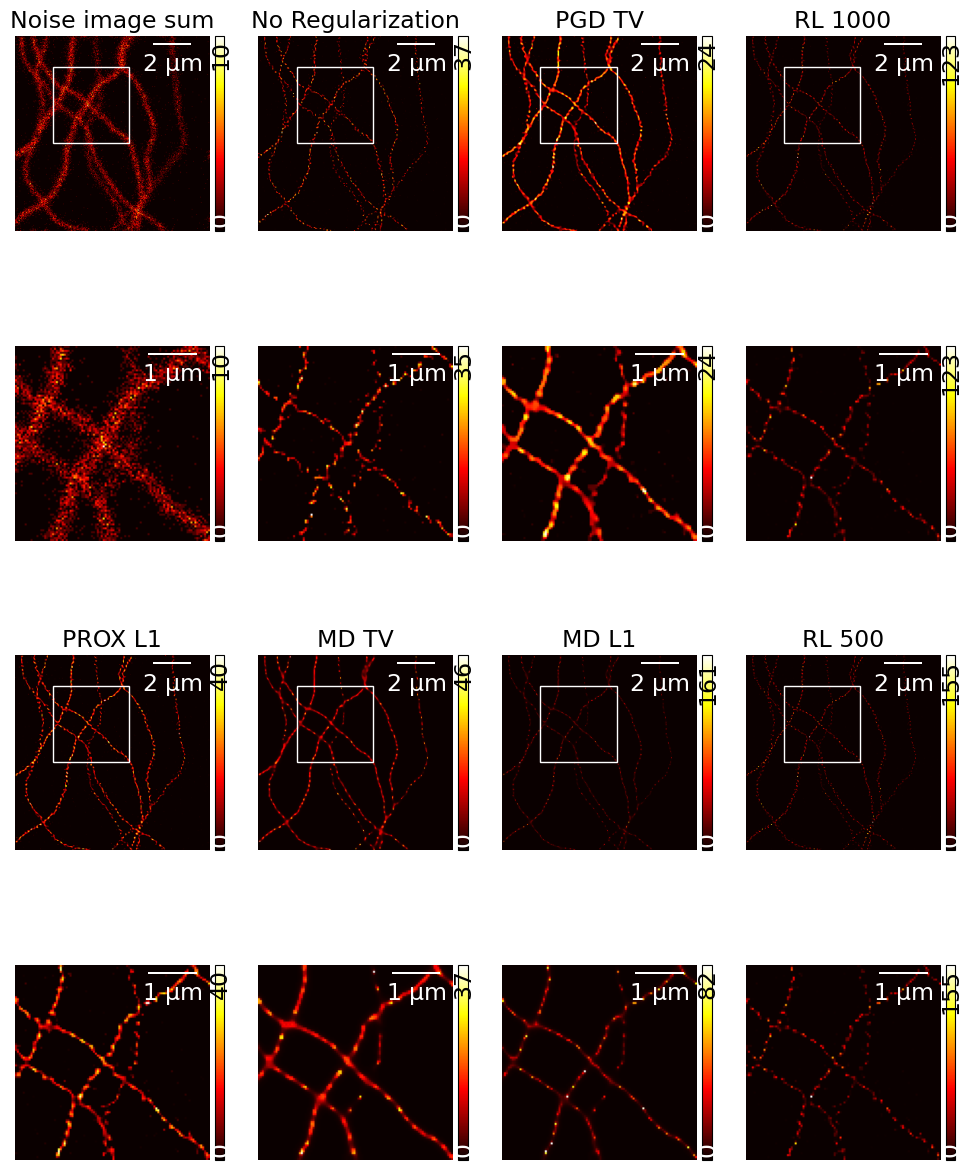

In [103]:
grid = ism.GridParameters()
grid.N = 5              # number of detector elements in each dimension
grid.pxsizex = hparams['pxsize']      # pixel size of the simulation space (nm)
grid.pxdim = 50e3       # detector element size in real space (nm)
grid.pxpitch = 75e3     # detector element pitch in real space (nm)
grid.M = 500            # total magnification of the optical system (e.g. 100x objective followed by 5x telescope)
grid.Nz = hparams['Nz']
grid.pxsizez = 700
exPar = ism.simSettings()
exPar.wl = 640 # excitation wavelength (nm)
exPar.mask_sampl = 31
emPar = exPar.copy()
emPar.wl = 660 # emission wavelength (nm)
z_shift = 0 #nm

# 4 righe x 3 colonne
fig, ax = plt.subplots(4, 4, sharex='row', sharey='row', figsize=(10, 13))

x0 = 40
y0 = 50
dx = 100
dy = 100

def get_rect():
    return patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')

# Nota: Assicurati di aver creato la griglia con 4 colonne:
# fig, ax = plt.subplots(4, 4, figsize=(...))

# ==========================================
# --- PARTE SUPERIORE (Righe 0 e 1) ---
# ==========================================

# --- 1. Top Col 0: Noise ---
gr.ShowImg(noise_image[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,0])
gr.ShowImg(noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,0])
ax[0,0].add_patch(get_rect()); ax[0,0].set_title("Noise image sum")

# --- 2. Top Col 1: No Regularization ---
gr.ShowImg(x_result_noreg[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,1])
gr.ShowImg(x_result_noreg[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,1])
ax[0,1].add_patch(get_rect()); ax[0,1].set_title("No Regularization")

# --- 3. Top Col 2: PGD (TV) ---
gr.ShowImg(x_result_tv[:,:,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[0,2])
gr.ShowImg(x_result_tv[:,:,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[1,2])
ax[0,2].add_patch(get_rect()); ax[0,2].set_title("PGD TV")

# --- 4. Top Col 3: RL 1000 (NUOVO) ---
gr.ShowImg(x_result_rl500[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,3])
gr.ShowImg(x_result_rl500[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,3])
ax[0,3].add_patch(get_rect()); ax[0,3].set_title("RL 1000")


# ==========================================
# --- PARTE INFERIORE (Righe 2 e 3) ---
# ==========================================

# --- 5. Bottom Col 0: PROX (L1) ---
gr.ShowImg(x_result_l1[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,0])
gr.ShowImg(x_result_l1[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,0])
ax[2,0].add_patch(get_rect()); ax[2,0].set_title("PROX L1")

# --- 6. Bottom Col 1: Mirror Descent (MD TV) ---
gr.ShowImg(x_result_mdtv[:,:,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[2,1])
gr.ShowImg(x_result_mdtv[:,:,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[3,1])
ax[2,1].add_patch(get_rect()); ax[2,1].set_title("MD TV")

# --- 7. Bottom Col 2: Mirror Descent (MD L1) ---
# Qui ho corretto la variabile da mdtv a mdl1 (assumendo che esista)
gr.ShowImg(x_result_mdl1[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,2])
gr.ShowImg(x_result_mdl1[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,2])
ax[2,2].add_patch(get_rect()); ax[2,2].set_title("MD L1")

# --- 8. Bottom Col 3: RL 500 (NUOVO) ---
gr.ShowImg(x_result_rl1000[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,3])
gr.ShowImg(x_result_rl1000[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,3])
ax[2,3].add_patch(get_rect()); ax[2,3].set_title("RL 500")

fig.tight_layout()

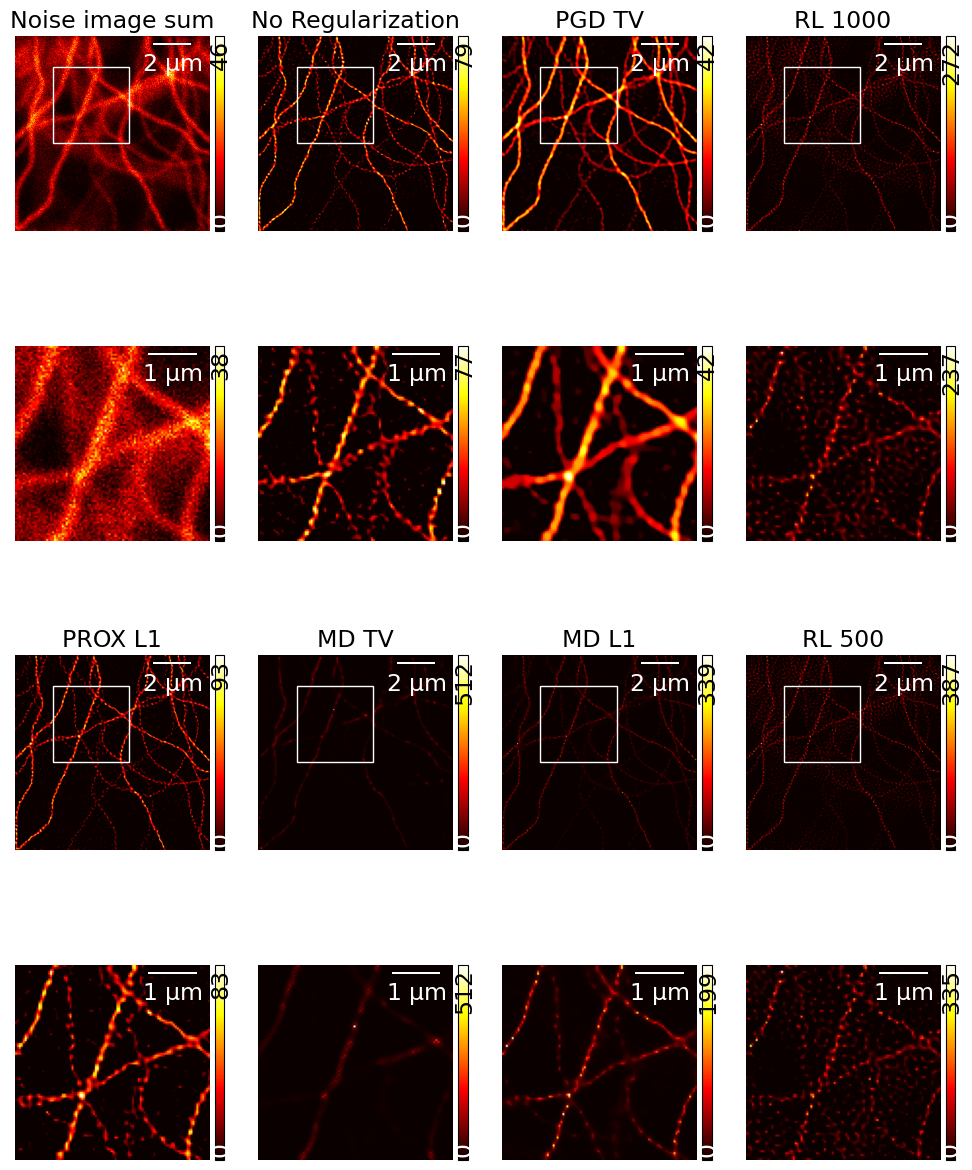

In [106]:
grid = ism.GridParameters()
grid.N = 5              # number of detector elements in each dimension
grid.pxsizex = hparams['pxsize']      # pixel size of the simulation space (nm)
grid.pxdim = 50e3       # detector element size in real space (nm)
grid.pxpitch = 75e3     # detector element pitch in real space (nm)
grid.M = 500            # total magnification of the optical system (e.g. 100x objective followed by 5x telescope)
grid.Nz = hparams['Nz']
grid.pxsizez = 700
exPar = ism.simSettings()
exPar.wl = 640 # excitation wavelength (nm)
exPar.mask_sampl = 31
emPar = exPar.copy()
emPar.wl = 660 # emission wavelength (nm)
z_shift = 0 #nm

# 4 righe x 3 colonne
fig, ax = plt.subplots(4, 4, sharex='row', sharey='row', figsize=(10, 13))

x0 = 40
y0 = 50
dx = 100
dy = 100

def get_rect():
    return patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')

# Nota: Assicurati di aver creato la griglia con 4 colonne:
# fig, ax = plt.subplots(4, 4, figsize=(...))

# ==========================================
# --- PARTE SUPERIORE (Righe 0 e 1) ---
# ==========================================

# --- 1. Top Col 0: Noise ---
gr.ShowImg(noise_image[:,:,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,0])
gr.ShowImg(noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,0])
ax[0,0].add_patch(get_rect()); ax[0,0].set_title("Noise image sum")

# --- 2. Top Col 1: No Regularization ---
gr.ShowImg(x_result_noreg[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,1])
gr.ShowImg(x_result_noreg[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,1])
ax[0,1].add_patch(get_rect()); ax[0,1].set_title("No Regularization")

# --- 3. Top Col 2: PGD (TV) ---
gr.ShowImg(x_result_tv[:,1:2,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[0,2])
gr.ShowImg(x_result_tv[:,1:2,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[1,2])
ax[0,2].add_patch(get_rect()); ax[0,2].set_title("PGD TV")

# --- 4. Top Col 3: RL 1000 (NUOVO) ---
gr.ShowImg(x_result_rl500[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[0,3])
gr.ShowImg(x_result_rl500[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[1,3])
ax[0,3].add_patch(get_rect()); ax[0,3].set_title("RL 1000")


# ==========================================
# --- PARTE INFERIORE (Righe 2 e 3) ---
# ==========================================

# --- 5. Bottom Col 0: PROX (L1) ---
gr.ShowImg(x_result_l1[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,0])
gr.ShowImg(x_result_l1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,0])
ax[2,0].add_patch(get_rect()); ax[2,0].set_title("PROX L1")

# --- 6. Bottom Col 1: Mirror Descent (MD TV) ---
gr.ShowImg(x_result_mdtv[:,1:2,:, :], grid.pxsizex*1e-3, fig=fig, ax=ax[2,1])
gr.ShowImg(x_result_mdtv[:,1:2,x0:x0+dx, y0:y0+dx], grid.pxsizex*1e-3, fig=fig, ax=ax[3,1])
ax[2,1].add_patch(get_rect()); ax[2,1].set_title("MD TV")

# --- 7. Bottom Col 2: Mirror Descent (MD L1) ---
# Qui ho corretto la variabile da mdtv a mdl1 (assumendo che esista)
gr.ShowImg(x_result_mdl1[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,2])
gr.ShowImg(x_result_mdl1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,2])
ax[2,2].add_patch(get_rect()); ax[2,2].set_title("MD L1")

# --- 8. Bottom Col 3: RL 500 (NUOVO) ---
gr.ShowImg(x_result_rl1000[:,1:2,:, :].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[2,3])
gr.ShowImg(x_result_rl1000[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), grid.pxsizex*1e-3, fig=fig, ax=ax[3,3])
ax[2,3].add_patch(get_rect()); ax[2,3].set_title("RL 500")

fig.tight_layout()

In [107]:
# Definiamo una lista di configurazioni aggiornata
sec = "3D"
tasks = [
    # --- RIGA 0 & 1: Baseline (Noise, NoReg, PGD TV) ---
    (noise_image.sum(0), f"{name_to_load}_{sec}_noise_full"),
    (x_result_noreg[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_noreg_full"),
    (x_result_tv[:,1:2,:, :], f"{name_to_load}_{sec}_pgd_tv_full"),
    
    (noise_image[:,:,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_noise_crop"),
    (x_result_noreg[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_noreg_crop"),
    (x_result_tv[:,1:2,x0:x0+dx, y0:y0+dx], f"{name_to_load}_{sec}_pgd_tv_crop"),
    
    # --- RIGA 2 & 3: Standard Reg (Prox L1, MD TV, MD L1) ---
    (x_result_l1[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_prox_l1_full"),
    (x_result_mdtv[:,1:2,:, :], f"{name_to_load}_{sec}_md_tv_full"),
    (x_result_mdl1[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_md_l1_full"),
    
    (x_result_l1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_prox_l1_crop"),
    (x_result_mdtv[:,1:2,x0:x0+dx, y0:y0+dx], f"{name_to_load}_{sec}_md_tv_crop"),
    (x_result_mdl1[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_md_l1_crop"),

    # --- NUOVI: RL 1000 ---
    (x_result_rl1000[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_rl1000_full"),
    (x_result_rl1000[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_rl1000_crop"),

    # --- NUOVI: RL 500 ---
    (x_result_rl500[:,1:2,:, :].sum(0), f"{name_to_load}_{sec}_rl100_full"),
    (x_result_rl500[:,1:2,x0:x0+dx, y0:y0+dx].sum(0), f"{name_to_load}_{sec}_rl100_crop")
]

for data, name in tasks:
    print(f"Processando: {name}")
    
    # 1. Visualizzazione
    fig, ax = gr.ShowImg(data, grid.pxsizex*1e-3)
    
    # 2. Rettangolo per il crop (opzionale, commentato come nel tuo originale)
    if "full" in name:
        rect = patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
    
    # 3. Salvataggio in PDF
    # Cambiato da .eps a .pdf
    output_name = f"{name}.pdf" 
    
    # Cambiato format='eps' a format='pdf'
    # Manteniamo dpi=300 e bbox_inches='tight' per la massima qualità
    fig.savefig(output_name, format='pdf', bbox_inches='tight', dpi=300)
    
    # 4. Cleanup
    plt.close(fig)
    print(f"Salvato con successo: {output_name}")

Processando: tubulin_3D_noise_full
Salvato con successo: tubulin_3D_noise_full.pdf
Processando: tubulin_3D_noreg_full
Salvato con successo: tubulin_3D_noreg_full.pdf
Processando: tubulin_3D_pgd_tv_full
Salvato con successo: tubulin_3D_pgd_tv_full.pdf
Processando: tubulin_3D_noise_crop
Salvato con successo: tubulin_3D_noise_crop.pdf
Processando: tubulin_3D_noreg_crop
Salvato con successo: tubulin_3D_noreg_crop.pdf
Processando: tubulin_3D_pgd_tv_crop
Salvato con successo: tubulin_3D_pgd_tv_crop.pdf
Processando: tubulin_3D_prox_l1_full
Salvato con successo: tubulin_3D_prox_l1_full.pdf
Processando: tubulin_3D_md_tv_full
Salvato con successo: tubulin_3D_md_tv_full.pdf
Processando: tubulin_3D_md_l1_full
Salvato con successo: tubulin_3D_md_l1_full.pdf
Processando: tubulin_3D_prox_l1_crop
Salvato con successo: tubulin_3D_prox_l1_crop.pdf
Processando: tubulin_3D_md_tv_crop
Salvato con successo: tubulin_3D_md_tv_crop.pdf
Processando: tubulin_3D_md_l1_crop
Salvato con successo: tubulin_3D_md_l1_c

In [96]:
name = "gt_tub2d"
data = dataset['ground_truth']
print(f"Processando: {name}")

# 1. Visualizzazione
fig, ax = gr.ShowImg(data, grid.pxsizex*1e-3)

# 2. Rettangolo per il crop (opzionale, commentato come nel tuo originale)
# if "full" in name:
#     rect = patches.Rectangle((y0, x0), dy, dx, linewidth=1, edgecolor='w', facecolor='none')
#     ax.add_patch(rect)

# 3. Salvataggio in PDF
# Cambiato da .eps a .pdf
output_name = f"{name}.pdf" 

# Cambiato format='eps' a format='pdf'
# Manteniamo dpi=300 e bbox_inches='tight' per la massima qualità
fig.savefig(output_name, format='pdf', bbox_inches='tight', dpi=300)

# 4. Cleanup
plt.close(fig)
print(f"Salvato con successo: {output_name}")

Processando: gt_tub2d
Salvato con successo: gt_tub2d.pdf


# OPTIM WP

In [9]:
# path = "Results/WP/wp_3D_pgd_masked_06_convallaria.pth"
mask_type = 'masked'                 # whole, masked, masked_eps
algo_to_load = "pgd"                # pgd or prox or md
name_to_load = "02_tomm20"     # tubulin for sim
sect_to_load = "3D"                 # 3D or 2D

path = f"Results/WP/wp_optim_{sect_to_load}_{algo_to_load}_{mask_type}_{name_to_load}.pth"


checkpoint = torch.load(path, weights_only = False)
results = checkpoint['results_optim']
best_result = results['results_best']
dataset = checkpoint['dataset']
hparams = checkpoint['hparams']


print(f" Miglior mu trovato: {results['best_mu']:.6f} con RWP = {results['rwp_vec'].min():.4f}")

plt.plot(results['rwp_vec'][100:].cpu())

plot_results(best_result, dataset, hparams['IS_REAL'], hparams['IS_3D'], hparams['pxsize'], x0_sec = 100, y0_sec = 100)


FileNotFoundError: [Errno 2] No such file or directory: 'Results/WP/wp_optim_3D_pgd_masked_02_tomm20.pth'

In [16]:
import subprocess
from pathlib import Path

def converti_veloce():
    input_dir = Path("Images_eps")
    output_dir = Path("Images_pdf")
    output_dir.mkdir(exist_ok=True)

    for eps_file in input_dir.glob("*.eps"):
        pdf_file = output_dir / (eps_file.stem + ".pdf")
        try:
            # shell=True permette di usare i comandi di sistema direttamente
            subprocess.run(["epstopdf", str(eps_file), f"--outfile={str(pdf_file)}"], check=True)
            print(f"✅ {eps_file.name} convertito.")
        except Exception as e:
            print(f"❌ Errore su {eps_file.name}: {e}")

converti_veloce()

✅ 01_tomm20_md_tv_crop.eps convertito.
✅ 01_tomm20_md_tv_full.eps convertito.
✅ 01_tomm20_noise_crop.eps convertito.
✅ 01_tomm20_noise_full.eps convertito.
✅ 01_tomm20_noreg_crop.eps convertito.
✅ 01_tomm20_noreg_full.eps convertito.
✅ 01_tomm20_pgd_tv_crop.eps convertito.
✅ 01_tomm20_pgd_tv_full.eps convertito.
✅ 01_tomm20_prox_l1_crop.eps convertito.
✅ 01_tomm20_prox_l1_full.eps convertito.
✅ 02_tomm20_md_tv_crop.eps convertito.
✅ 02_tomm20_md_tv_full.eps convertito.
✅ 02_tomm20_noise_crop.eps convertito.
✅ 02_tomm20_noise_full.eps convertito.
✅ 02_tomm20_noreg_crop.eps convertito.
✅ 02_tomm20_noreg_full.eps convertito.
✅ 02_tomm20_pgd_tv_crop.eps convertito.
✅ 02_tomm20_pgd_tv_full.eps convertito.
✅ 02_tomm20_prox_l1_crop.eps convertito.
✅ 02_tomm20_prox_l1_full.eps convertito.
✅ 03_tomm20_md_tv_crop.eps convertito.
✅ 03_tomm20_md_tv_full.eps convertito.
✅ 03_tomm20_noise_crop.eps convertito.
✅ 03_tomm20_noise_full.eps convertito.
✅ 03_tomm20_noreg_crop.eps convertito.
✅ 03_tomm20_n

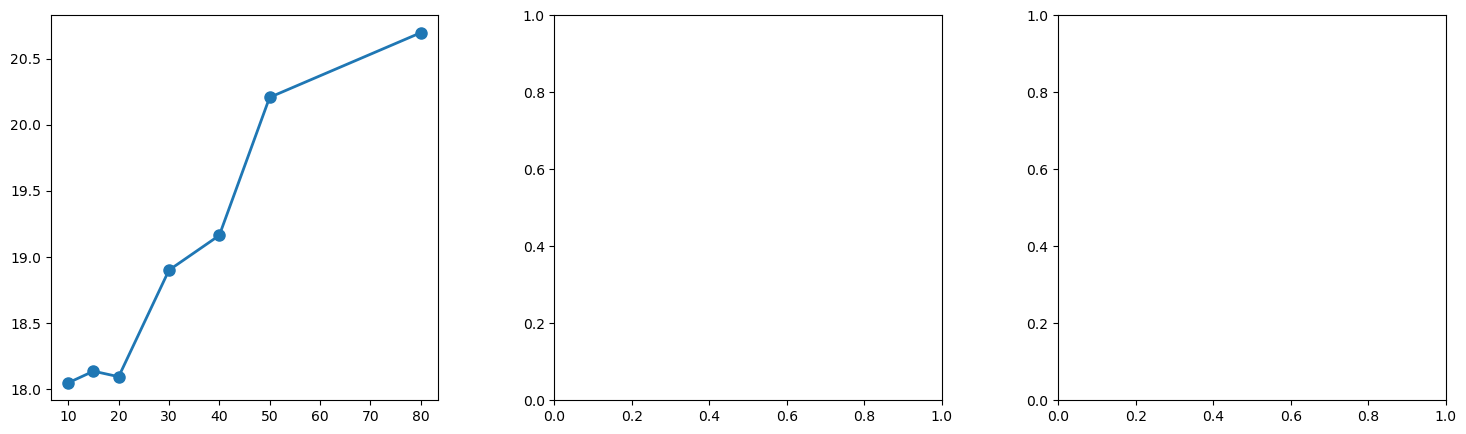

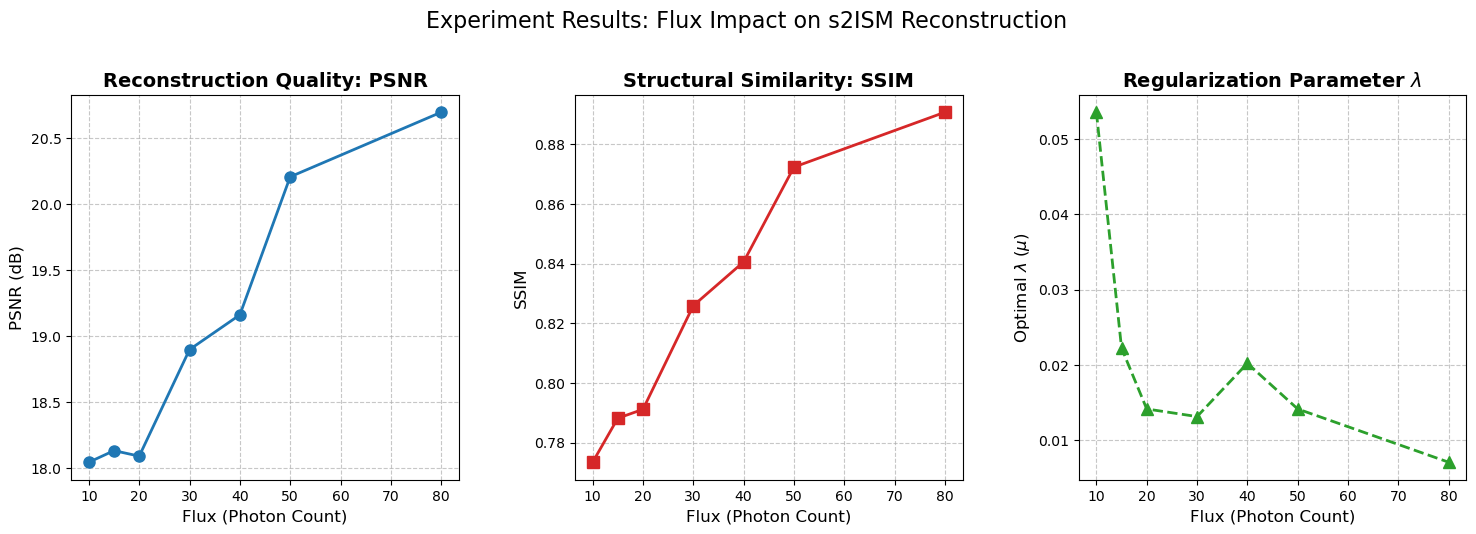

Flux       | PSNR       | SSIM       | Best Lambda
--------------------------------------------------
10         | 18.05      | 0.7734     | 5.35e-02  
15         | 18.13      | 0.7882     | 2.22e-02  
20         | 18.09      | 0.7911     | 1.41e-02  
30         | 18.90      | 0.8259     | 1.31e-02  
40         | 19.16      | 0.8406     | 2.02e-02  
50         | 20.21      | 0.8724     | 1.41e-02  
80         | 20.70      | 0.8908     | 7.07e-03  


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# 1. Imposta il percorso del file salvato
# Assicurati che il percorso sia corretto rispetto alla posizione del notebook
file_path = Path("Results/Experiment_Flux_MultiRealization/experiment_avg_pgd.pth")

if not file_path.exists():
    print(f"Errore: Il file {file_path} non esiste. Controlla il percorso!")
else:
    # 2. Carica i dati
    history = torch.load(file_path)

    # Estraiamo i valori (convertendoli in liste se sono tensori)
    # 2. Carica i dati
    history = torch.load(file_path)


    # Convertiamo le liste in tensori, spostiamoli su CPU e trasformiamoli in Numpy per il plot
    # Usiamo torch.as_tensor() perché è efficiente
    flux = torch.as_tensor(history['flux']).cpu().numpy()
    psnr = torch.as_tensor(history['psnr_mean']).cpu().numpy()
    ssim = torch.as_tensor(history['ssim_mean']).cpu().numpy()
    lambdas = torch.as_tensor(history['best_mu_mean']).cpu().numpy()

    # Prepariamo la figura con 3 grafici
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)

    # --- Grafico 1: PSNR vs Flux ---
    # Ora flux e psnr sono array Numpy, Matplotlib li adora
    axs[0].plot(flux, psnr, 'o-', color='tab:blue', linewidth=2, markersize=8)
    # ... resto del codice invariato ...

    # Prepariamo la figura con 3 grafici
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    plt.subplots_adjust(wspace=0.3)

    # --- Grafico 1: PSNR vs Flux ---
    axs[0].plot(flux, psnr, 'o-', color='tab:blue', linewidth=2, markersize=8)
    axs[0].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[0].set_ylabel('PSNR (dB)', fontsize=12)
    axs[0].set_title('Reconstruction Quality: PSNR', fontsize=14, fontweight='bold')
    axs[0].grid(True, linestyle='--', alpha=0.7)

    # --- Grafico 2: SSIM vs Flux ---
    axs[1].plot(flux, ssim, 's-', color='tab:red', linewidth=2, markersize=8)
    axs[1].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[1].set_ylabel('SSIM', fontsize=12)
    axs[1].set_title('Structural Similarity: SSIM', fontsize=14, fontweight='bold')
    axs[1].grid(True, linestyle='--', alpha=0.7)

    # --- Grafico 3: Lambda (Best Mu) vs Flux ---
    axs[2].plot(flux, lambdas, '^--', color='tab:green', linewidth=2, markersize=8)
    axs[2].set_xlabel('Flux (Photon Count)', fontsize=12)
    axs[2].set_ylabel(r'Optimal $\lambda$ ($\mu$)', fontsize=12)
    axs[2].set_title('Regularization Parameter $\lambda$', fontsize=14, fontweight='bold')
    axs[2].grid(True, linestyle='--', alpha=0.7)
    # Spesso lambda varia di ordini di grandezza, se necessario scommenta la riga sotto:
    # axs[2].set_yscale('log') 

    plt.suptitle('Experiment Results: Flux Impact on s2ISM Reconstruction', fontsize=16, y=1.05)
    
    # Salva il riepilogo in PDF
    plt.savefig(file_path.parent / "summary_plots.pdf", bbox_inches='tight')
    plt.show()

    # 3. Stampa una tabella veloce dei valori
    print(f"{'Flux':<10} | {'PSNR':<10} | {'SSIM':<10} | {'Best Lambda':<10}")
    print("-" * 50)
    for f, p, s, l in zip(flux, psnr, ssim, lambdas):
        print(f"{f:<10} | {p:<10.2f} | {s:<10.4f} | {l:<10.2e}")
        
    
        
# for i in range(len(history['results'])):
#     plot(history['results'][i]['results_best']['x_result'], cmap = 'hot', subtitles= f'flux = {history["flux"][i]}')


In [25]:
print(history.keys())


dict_keys(['flux', 'psnr_mean', 'psnr_std', 'ssim_mean', 'ssim_std', 'best_mu_mean', 'raw_data'])


In [28]:
i = 0
print(history['flux'][i])
print(history['best_mu_mean'][i])

print(history['raw_data'][i]['mu_all'])


10
0.053536295890808105
tensor([9.0910e-02, 3.0304e-02, 3.0304e-02, 4.0405e-02, 1.0000e-06, 1.0000e-06,
        1.0102e-02, 1.1111e-01, 9.0910e-02, 1.3131e-01])
